<a href="https://colab.research.google.com/github/karthik-garlapally/Machine_Lerning/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment-5

Apply a suitable classifier model to classify the credit status to be good or bad on German credit data.csv. Create a confusion matrix to measure the accuracy of the fitted model. Apply it on logistic regression..

####importing pandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

####1.loading csv file

In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving german_credit_data.csv to german_credit_data (1).csv
User uploaded file "german_credit_data (1).csv" with length 53393 bytes


####2.Display first 5 records

In [ ]:
print("First 5 records:")
display(data.head())

First 5 records:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


####3. Display column names


In [ ]:
print("\nColumn names:")
print(data.columns)


Column names:
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


#### 4. Check for missing values

In [ ]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


#### 5. Separate input features (X) and target (y)

In [ ]:
X = data.drop("Risk", axis=1)
y = data["Risk"]

####6. Remove unnecessary column if present

In [ ]:
if "Unnamed: 0" in X.columns:
    X = X.drop("Unnamed: 0", axis=1)

#### 7. Convert categorical variables into numerical variables


In [ ]:
X = pd.get_dummies(X, drop_first=True)

#### 8. Convert target Good/Bad into 1/0


In [ ]:
y = y.map({"good": 1, "bad": 0})

#### 9. Split the dataset into training and testing sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

####10. Standardize the features

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

####11. Create Logistic Regression model

In [ ]:
model = LogisticRegression(max_iter=1000)

####12. Train the model

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

####13. Make predictions

In [ ]:
y_pred = model.predict(X_test)

#### 14. Calculate accuracy


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Accuracy: 0.7
Accuracy Percentage: 70.0 %


#### 15. Create confusion matrix


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 15  45]
 [ 15 125]]


##### 16. Display confusion matrix


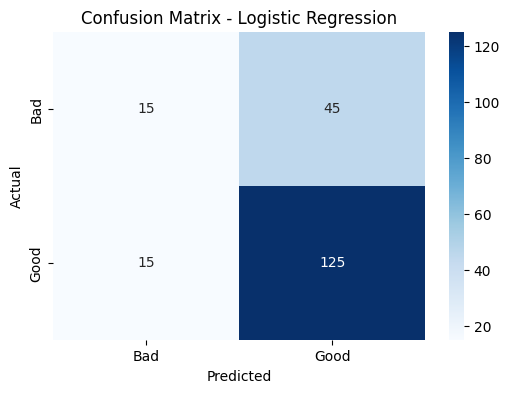

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad", "Good"],
    yticklabels=["Bad", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### 17. Classification report


In [ ]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Bad", "Good"]
))


Classification Report:
              precision    recall  f1-score   support

         Bad       0.50      0.25      0.33        60
        Good       0.74      0.89      0.81       140

    accuracy                           0.70       200
   macro avg       0.62      0.57      0.57       200
weighted avg       0.66      0.70      0.66       200

